<a href="https://colab.research.google.com/github/ZahranAzariaAnvaya/ZahranAzariaAnvaya_2411531005_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# load dataset
dataset_url = 'https://raw.githubusercontent.com/ZahranAzariaAnvaya/ZahranAzariaAnvaya_2411531005_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [3]:
# Pisahkan fitur dan target
feature_cols = ['mean_radius','mean_texture','mean_perimeter','mean_area','mean_smoothness']
X = df[feature_cols]   # Features
y = df.diagnosis       # Target (0 = benign, 1 = malignant)

In [4]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)

# **Model dengan Scalling**

In [5]:
# Scaling data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Latih model dengan scaling
logreg_scaling = LogisticRegression(max_iter=10000, random_state=16)
logreg_scaling.fit(X_train_scaled, y_train)
# Probabilitas prediksi
y_pred_proba_yes = logreg_scaling.predict_proba(X_test_scaled)[:,1]

In [7]:
# Threshold 0.5
y_pred_yes_05 = (y_pred_proba_yes >= 0.5).astype(int)

print("=== DENGAN scaling, threshold=0.5 ===")
print(classification_report(y_test, y_pred_yes_05, target_names=['benign','malignant']))

=== DENGAN scaling, threshold=0.5 ===
              precision    recall  f1-score   support

      benign       0.94      0.91      0.92        65
   malignant       0.94      0.96      0.95       106

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



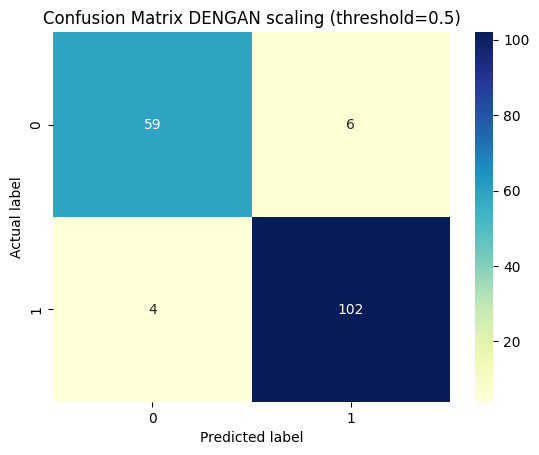

In [8]:
# Prediksi dengan threshold 0.5
y_pred_yes_05 = (y_pred_proba_yes >= 0.5).astype(int)
cnf_matrix_yes_05 = confusion_matrix(y_test, y_pred_yes_05)

sns.heatmap(pd.DataFrame(cnf_matrix_yes_05), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix DENGAN scaling (threshold=0.5)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

In [9]:
# Threshold 0.3
y_pred_yes_03 = (y_pred_proba_yes >= 0.3).astype(int)
print("=== DENGAN scaling, threshold=0.3 ===")
print(classification_report(y_test, y_pred_yes_03, target_names=['benign','malignant']))

=== DENGAN scaling, threshold=0.3 ===
              precision    recall  f1-score   support

      benign       0.98      0.85      0.91        65
   malignant       0.91      0.99      0.95       106

    accuracy                           0.94       171
   macro avg       0.95      0.92      0.93       171
weighted avg       0.94      0.94      0.93       171



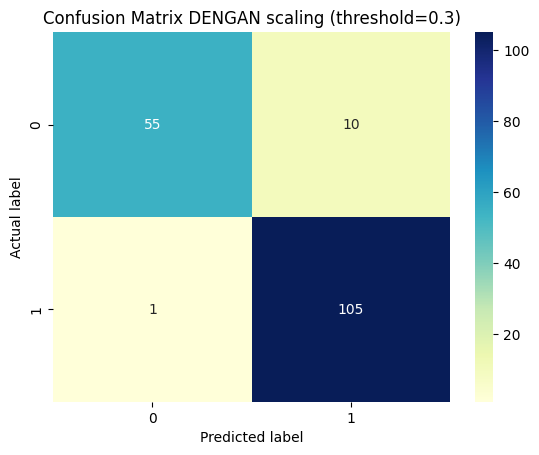

In [10]:
# Prediksi dengan threshold 0.3
y_pred_yes_03 = (y_pred_proba_yes >= 0.3).astype(int)
cnf_matrix_yes_03 = confusion_matrix(y_test, y_pred_yes_03)

sns.heatmap(pd.DataFrame(cnf_matrix_yes_03), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix DENGAN scaling (threshold=0.3)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

In [11]:
# Threshold 0.7
y_pred_yes_07 = (y_pred_proba_yes >= 0.7).astype(int)
print("=== DENGAN scaling, threshold=0.7 ===")
print(classification_report(y_test, y_pred_yes_07, target_names=['benign','malignant']))

=== DENGAN scaling, threshold=0.7 ===
              precision    recall  f1-score   support

      benign       0.85      0.94      0.89        65
   malignant       0.96      0.90      0.93       106

    accuracy                           0.91       171
   macro avg       0.90      0.92      0.91       171
weighted avg       0.92      0.91      0.91       171



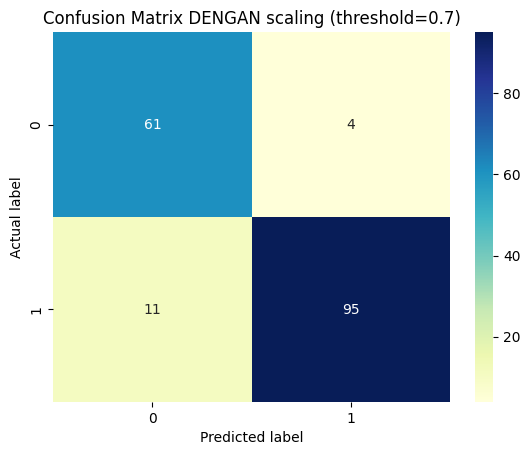

In [12]:
# Prediksi dengan threshold 0.7
y_pred_yes_07 = (y_pred_proba_yes >= 0.7).astype(int)
cnf_matrix_yes_07 = confusion_matrix(y_test, y_pred_yes_07)

sns.heatmap(pd.DataFrame(cnf_matrix_yes_07), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix DENGAN scaling (threshold=0.7)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

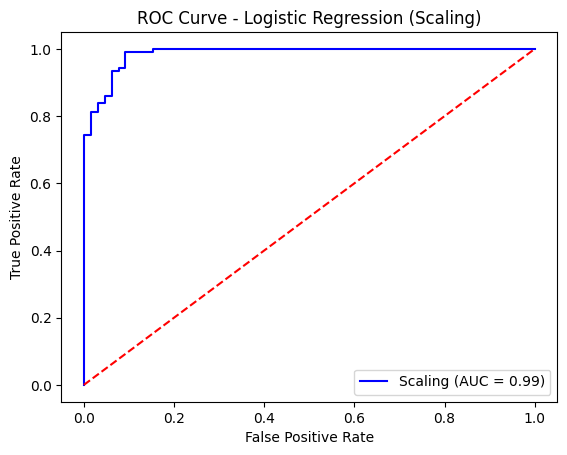

In [13]:
fpr_scale, tpr_scale, thresholds_scale = roc_curve(y_test, y_pred_proba_yes)
roc_auc_scale = roc_auc_score(y_test, y_pred_proba_yes)

plt.figure()
plt.plot(fpr_scale, tpr_scale, color='blue', label='Scaling (AUC = %0.2f)' % roc_auc_scale)
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (Scaling)')
plt.legend(loc="lower right")
plt.show()

# **Model Tanpa Scalling**


In [14]:
# Latih model tanpa scaling
logreg_no_scaling = LogisticRegression(max_iter=10000, random_state=16)
logreg_no_scaling.fit(X_train, y_train)
y_pred_proba_no = logreg_no_scaling.predict_proba(X_test)[:,1]

In [15]:
# Threshold 0.5
y_pred_no_05 = (y_pred_proba_no >= 0.5).astype(int)
print("=== Threshold = 0.5 ===")
print(classification_report(y_test, y_pred_no_05, target_names=['benign','malignant']))

=== Threshold = 0.5 ===
              precision    recall  f1-score   support

      benign       0.88      0.86      0.87        65
   malignant       0.92      0.92      0.92       106

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



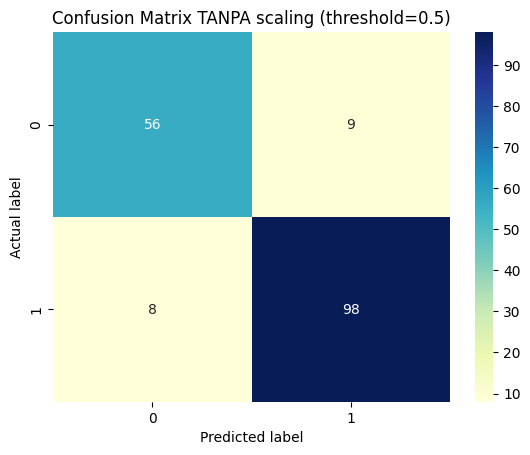

In [16]:
# Threshold 0.5
y_pred_no_05 = (y_pred_proba_no >= 0.5).astype(int)
cnf_matrix_no_05 = confusion_matrix(y_test, y_pred_no_05)
sns.heatmap(pd.DataFrame(cnf_matrix_no_05), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix TANPA scaling (threshold=0.5)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

In [17]:
# Threshold 0.3
y_pred_no_03 = (y_pred_proba_no >= 0.3).astype(int)
print("=== Threshold = 0.3 ===")
print(classification_report(y_test, y_pred_no_03, target_names=['benign','malignant']))


=== Threshold = 0.3 ===
              precision    recall  f1-score   support

      benign       0.95      0.80      0.87        65
   malignant       0.89      0.97      0.93       106

    accuracy                           0.91       171
   macro avg       0.92      0.89      0.90       171
weighted avg       0.91      0.91      0.90       171



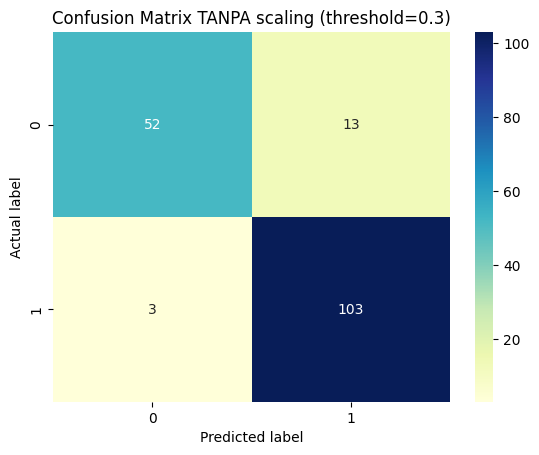

In [18]:
# Threshold 0.3
y_pred_no_03 = (y_pred_proba_no >= 0.3).astype(int)
cnf_matrix_no_03 = confusion_matrix(y_test, y_pred_no_03)
sns.heatmap(pd.DataFrame(cnf_matrix_no_03), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix TANPA scaling (threshold=0.3)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

In [19]:
# Threshold 0.7
y_pred_no_07 = (y_pred_proba_no >= 0.7).astype(int)
print("=== Threshold = 0.7 ===")
print(classification_report(y_test, y_pred_no_07, target_names=['benign','malignant']))

=== Threshold = 0.7 ===
              precision    recall  f1-score   support

      benign       0.79      0.89      0.84        65
   malignant       0.93      0.86      0.89       106

    accuracy                           0.87       171
   macro avg       0.86      0.88      0.87       171
weighted avg       0.88      0.87      0.87       171



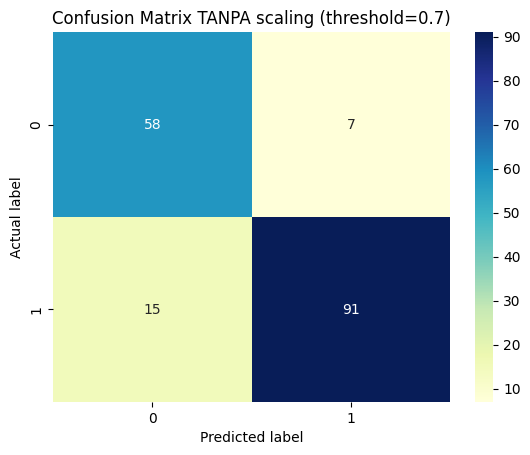

In [20]:
# Threshold 0.7
y_pred_no_07 = (y_pred_proba_no >= 0.7).astype(int)
cnf_matrix_no_01 = confusion_matrix(y_test, y_pred_no_07)
sns.heatmap(pd.DataFrame(cnf_matrix_no_01), annot=True, cmap="YlGnBu", fmt='g')
plt.title("Confusion Matrix TANPA scaling (threshold=0.7)")
plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.show()

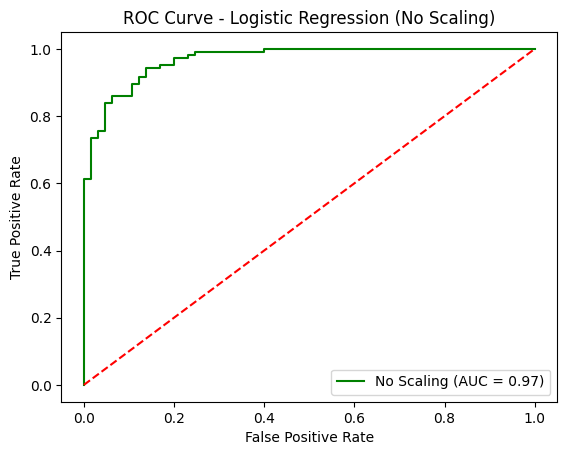

In [21]:
fpr_no, tpr_no, thresholds_no = roc_curve(y_test, y_pred_proba_no)
roc_auc_no = roc_auc_score(y_test, y_pred_proba_no)

# Plot ROC curve
plt.figure()
plt.plot(fpr_no, tpr_no, color='green', label='No Scaling (AUC = %0.2f)' % roc_auc_no)
plt.plot([0,1],[0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (No Scaling)')
plt.legend(loc="lower right")
plt.show()